# EDA
This notebook explores the EEGMAT dataset before any modelling.
Dataset is already prefiltered and artifacts are removed using ICA.

Goals:
1. Verify data structure and basic quality
2. Inspect raw EEG signals across conditions
3. Characterise frequency-band power differences (rest vs. mental math)
4. Check subject variability and class balance

## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from pathlib import Path
import mne
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_raw_data
from src.preprocessing import epoch_recordings
from src.features import extract_features

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'rest': '#4878CF', 'mental_math': '#D65F5F'}
DATA_DIR = Path('../data/raw')
SFREQ = 500  # Hz

## 1. Load Dataset

In [17]:
raw = load_raw_data(DATA_DIR)
X, labels = epoch_recordings(recordings=raw, epoch_duration=2.0, overlap=0)

subject_ids   = labels['subject_id']
session_types = labels['session_type']  # 1 = rest, 2 = mental math
y = (session_types == 2).astype(int)   # binary: 0 = rest, 1 = mental math

print(f'Dataset shape : {X.shape}  (epochs x channels x samples)')
print(f'Subjects      : {np.unique(subject_ids).size}')
print(f'Class balance : rest={(y==0).sum()} | mental_math={(y==1).sum()}')
print(f'Epoch length  : 2 s  |  Overlap: 0%  |  Sfreq: {SFREQ} Hz')

Dataset shape : (4338, 21, 1000)  (epochs x channels x samples)
Subjects      : 36
Class balance : rest=3222 | mental_math=1116
Epoch length  : 2 s  |  Overlap: 0%  |  Sfreq: 500 Hz


In [3]:
# Inspect channel metadata from one raw EDF
sample_edf = sorted(DATA_DIR.glob('Subject*_1.edf'))[0]
raw = mne.io.read_raw_edf(str(sample_edf), preload=False, verbose=False)
ch_names = raw.ch_names

print(f'Channels ({len(ch_names)}): {ch_names}')
print(f'Duration  : {raw.times[-1]:.1f} s')
print(f'Sfreq     : {raw.info["sfreq"]} Hz')

Channels (21): ['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']
Duration  : 182.0 s
Sfreq     : 500.0 Hz


## 2. Dataset Structure

Each EDF file is one 180-second (rest) or 60-second (mental math) recording. With a 2-second epoch window and 0% overlap for clarity.

In [4]:
df_meta = pd.DataFrame({
    'subject_id': subject_ids,
    'condition':  np.where(y == 0, 'rest', 'mental_math')
})

epochs_per_subject = (
    df_meta.groupby(['subject_id', 'condition'])
    .size().unstack(fill_value=0).rename_axis(None, axis=1)
)

print(epochs_per_subject.describe().round(1))

       mental_math  rest
count         36.0  36.0
mean          31.0  89.5
std            0.0   8.6
min           31.0  40.0
25%           31.0  91.0
50%           31.0  91.0
75%           31.0  91.0
max           31.0  94.0


## 3. Raw EEG Signal Visualization

Compare a 2-second epoch of three channels under rest vs. mental math for one subject.

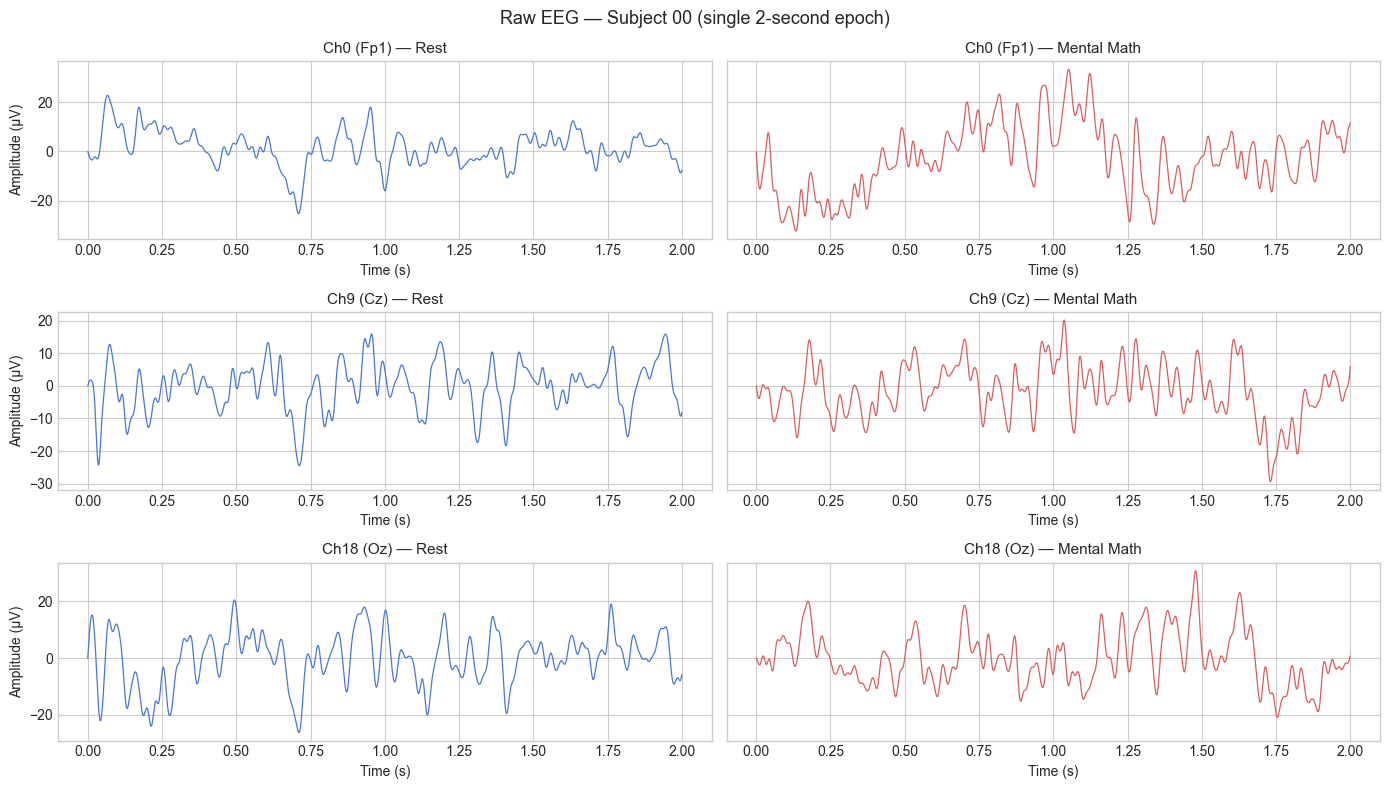

In [5]:
n_ch    = X.shape[1]
ch_plot = [
    (0,                 'Ch0 (Fp1)'),
    (min(9,  n_ch-1),  f'Ch{min(9,n_ch-1)} (Cz)'),
    (min(18, n_ch-1),  f'Ch{min(18,n_ch-1)} (Oz)'),
]

subj     = np.unique(subject_ids)[0]
rest_idx = np.where((subject_ids == subj) & (y == 0))[0][0]
math_idx = np.where((subject_ids == subj) & (y == 1))[0][0]
t        = np.linspace(0, 2, X.shape[2])

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharey='row')
fig.suptitle(f'Raw EEG — Subject {subj:02d} (single 2-second epoch)', fontsize=13)

for row, (ch_idx, ch_label) in enumerate(ch_plot):
    for col, (epoch_idx, cond, color) in enumerate([
        (rest_idx, 'Rest',        COLORS['rest']),
        (math_idx, 'Mental Math', COLORS['mental_math'])
    ]):
        ax = axes[row, col]
        ax.plot(t, X[epoch_idx, ch_idx], color=color, linewidth=0.9)
        ax.set_title(f'{ch_label} — {cond}', fontsize=11)
        ax.set_xlabel('Time (s)')
        if col == 0:
            ax.set_ylabel('Amplitude (µV)')

plt.tight_layout()
plt.show()

## 4. Power Spectral Density — Rest vs. Mental Math

Welch's method on frontal and central regions. Expected: elevated theta (4–8 Hz) and beta (12–30 Hz) during mental arithmetic.

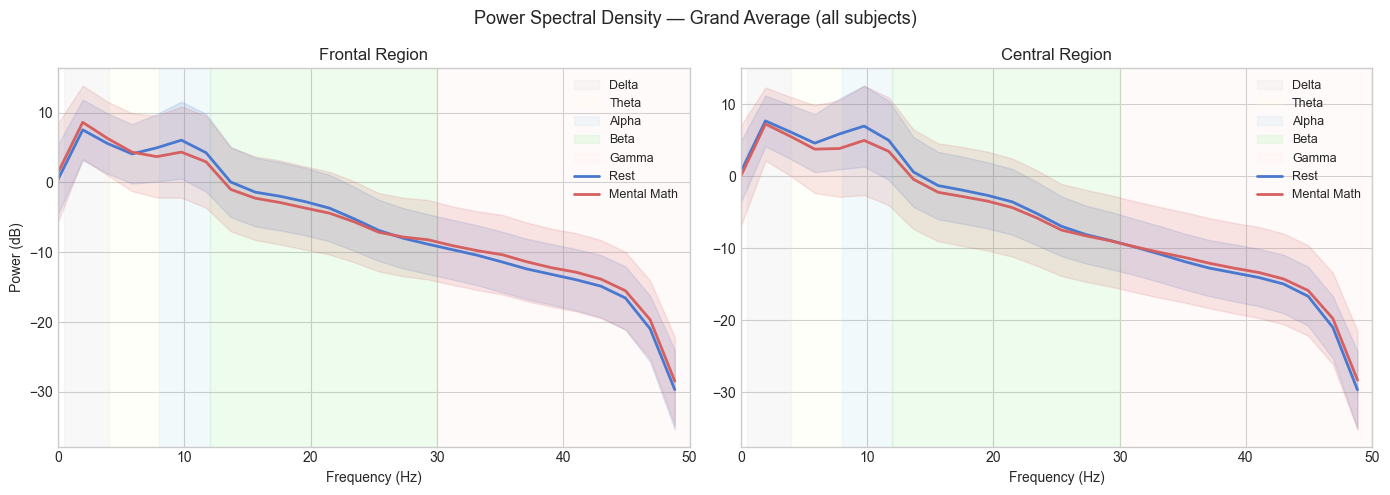

In [6]:
FRONTAL  = [i for i in [0, 1, 2, 3, 4] if i < n_ch]
CENTRAL  = [i for i in [8, 9, 10]      if i < n_ch]

def avg_psd(epochs, channel_idxs, sfreq=SFREQ):
    psds = []
    for ep in epochs:
        reg = ep[channel_idxs].mean(axis=0)
        freqs, psd = signal.welch(reg, sfreq, nperseg=min(256, ep.shape[1]))
        psds.append(psd)
    return freqs, np.array(psds)

rest_epochs = X[y == 0]
math_epochs = X[y == 1]

freqs, rest_psd_f = avg_psd(rest_epochs, FRONTAL)
_,     math_psd_f = avg_psd(math_epochs, FRONTAL)
_,     rest_psd_c = avg_psd(rest_epochs, CENTRAL)
_,     math_psd_c = avg_psd(math_epochs, CENTRAL)
freq_mask = freqs <= 50

bands = [
    ('Delta',  0.5,  4,  'lightgray'),
    ('Theta',  4,    8,  'lightyellow'),
    ('Alpha',  8,   12,  'lightblue'),
    ('Beta',   12,  30,  'lightgreen'),
    ('Gamma',  30,  50,  'mistyrose'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Power Spectral Density — Grand Average (all subjects)', fontsize=13)

for ax, (psd_r, psd_m, region) in zip(axes, [
    (rest_psd_f, math_psd_f, 'Frontal'),
    (rest_psd_c, math_psd_c, 'Central'),
]):
    f   = freqs[freq_mask]
    r_m = 10 * np.log10(psd_r[:, freq_mask].mean(0) + 1e-12)
    r_s = 10 * np.log10(psd_r[:, freq_mask] + 1e-12).std(0)
    m_m = 10 * np.log10(psd_m[:, freq_mask].mean(0) + 1e-12)
    m_s = 10 * np.log10(psd_m[:, freq_mask] + 1e-12).std(0)

    for name, lo, hi, color in bands:
        ax.axvspan(lo, hi, alpha=0.15, color=color, label=name)
    ax.plot(f, r_m, color=COLORS['rest'],        lw=2, label='Rest')
    ax.fill_between(f, r_m-r_s, r_m+r_s, alpha=0.15, color=COLORS['rest'])
    ax.plot(f, m_m, color=COLORS['mental_math'], lw=2, label='Mental Math')
    ax.fill_between(f, m_m-m_s, m_m+m_s, alpha=0.15, color=COLORS['mental_math'])
    ax.set_title(f'{region} Region', fontsize=12)
    ax.set_xlabel('Frequency (Hz)')
    if ax is axes[0]:
        ax.set_ylabel('Power (dB)')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 50)

plt.tight_layout()
plt.show()

## 5. Frequency Band Power — Condition Comparison

Violin plots compare frontal band-power distributions across conditions.

**Expected:** Theta ↑, Alpha ↓, Beta ↑ under cognitive load.

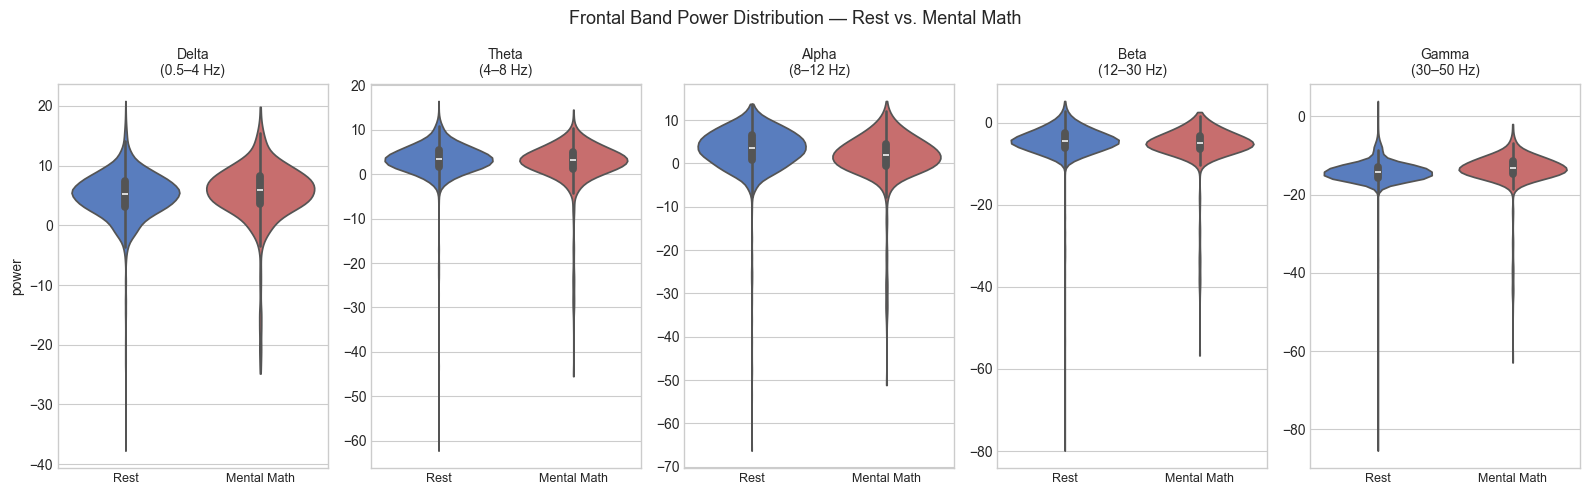

In [7]:
def band_power(psd_array, freqs, lo, hi):
    mask = (freqs >= lo) & (freqs < hi)
    return psd_array[:, mask].mean(axis=1)

BAND_DEFS = {
    'Delta\n(0.5–4 Hz)':  (0.5, 4),
    'Theta\n(4–8 Hz)':    (4,   8),
    'Alpha\n(8–12 Hz)':   (8,  12),
    'Beta\n(12–30 Hz)':   (12, 30),
    'Gamma\n(30–50 Hz)':  (30, 50),
}

all_psds = []
for ep in X:
    reg = ep[FRONTAL].mean(axis=0)
    _, psd = signal.welch(reg, SFREQ, nperseg=min(256, ep.shape[1]))
    all_psds.append(psd)
all_psds = np.array(all_psds)

fig, axes = plt.subplots(1, len(BAND_DEFS), figsize=(16, 5))
fig.suptitle('Frontal Band Power Distribution — Rest vs. Mental Math', fontsize=13)

for ax, (band_name, (lo, hi)) in zip(axes, BAND_DEFS.items()):
    bp_db = 10 * np.log10(band_power(all_psds, freqs, lo, hi) + 1e-12)
    data  = pd.DataFrame({'power': bp_db,
                          'condition': np.where(y==0, 'Rest', 'Mental Math')})
    sns.violinplot(data=data, x='condition', y='power', ax=ax,
                   palette={'Rest': COLORS['rest'],
                            'Mental Math': COLORS['mental_math']},
                   inner='box', cut=0)
    ax.set_title(band_name, fontsize=10)
    ax.set_xlabel('')
    if ax is not axes[0]:
        ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

## 6. Channel-Level Theta Change

Per-channel theta power difference (mental math − rest) reveals which scalp regions drive the classification signal.

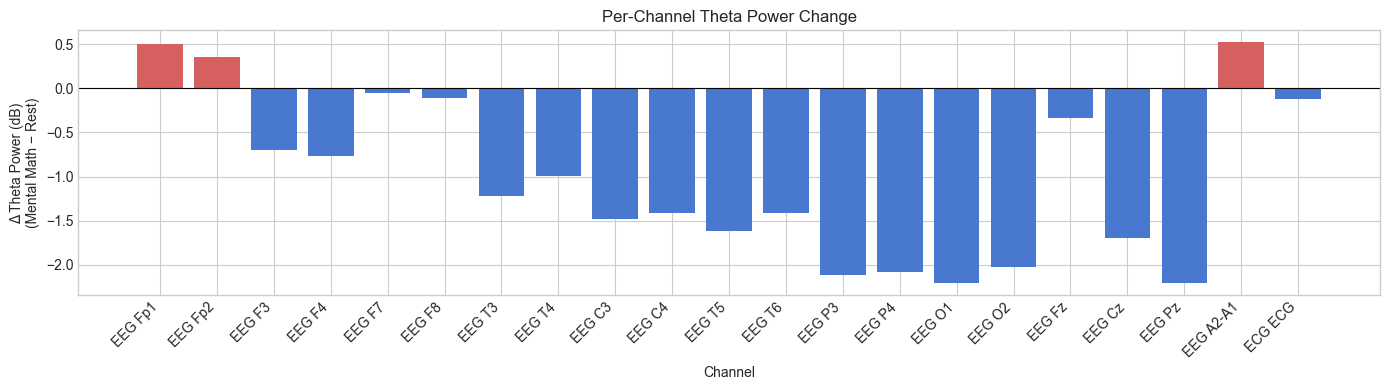

  EEG Pz  Δ = -2.21 dB
  EEG O1  Δ = -2.21 dB
  EEG P3  Δ = -2.11 dB


In [8]:
n_channels = X.shape[1]
theta_diff = np.zeros(n_channels)

for ch in range(n_channels):
    def _theta(epochs, ch=ch):
        vals = []
        for ep in epochs:
            f, p = signal.welch(ep[ch], SFREQ, nperseg=min(256, ep.shape[1]))
            vals.append(p[(f>=4)&(f<8)].mean())
        return np.mean(vals)
    theta_diff[ch] = 10*np.log10((_theta(math_epochs)+1e-12)/(_theta(rest_epochs)+1e-12))

ch_labels = ch_names[:n_channels] if len(ch_names)>=n_channels else [f'Ch{i}' for i in range(n_channels)]
bar_colors = ['#D65F5F' if d>0 else '#4878CF' for d in theta_diff]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(ch_labels, theta_diff, color=bar_colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Channel')
ax.set_ylabel('Δ Theta Power (dB)\n(Mental Math − Rest)')
ax.set_title('Per-Channel Theta Power Change')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top3 = np.argsort(np.abs(theta_diff))[-3:][::-1]
for idx in top3:
    print(f'  {ch_labels[idx]:6s}  Δ = {theta_diff[idx]:+.2f} dB')

## 7. Subject Variability

High inter-subject variance is a core challenge in EEG. This section quantifies how much individuals differ in their theta response.

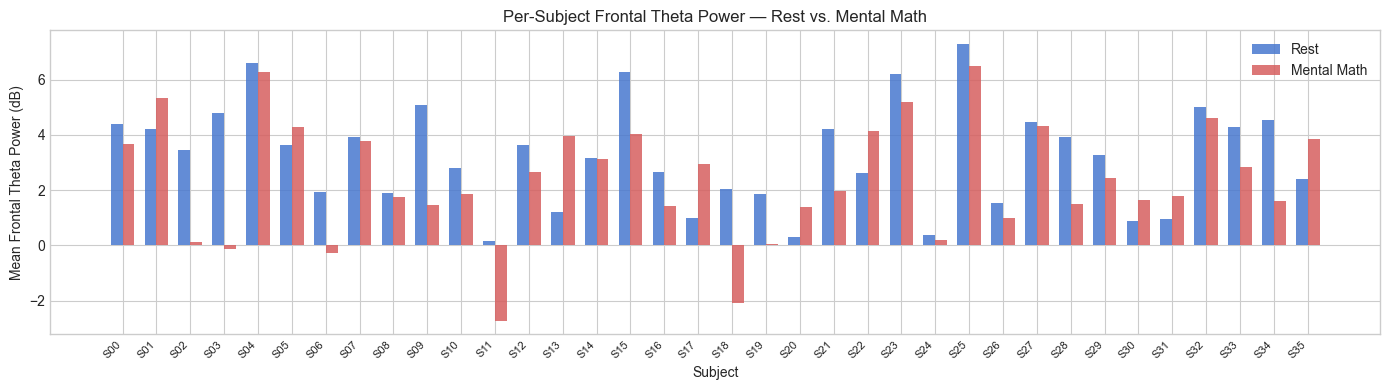

In [9]:
unique_subjects = np.unique(subject_ids)

def mean_frontal_theta(epochs):
    vals = []
    for ep in epochs:
        reg = ep[FRONTAL].mean(axis=0)
        f, p = signal.welch(reg, SFREQ, nperseg=min(256, ep.shape[1]))
        vals.append(10*np.log10(p[(f>=4)&(f<8)].mean()+1e-12))
    return np.mean(vals) if vals else np.nan

subj_rest_theta = [mean_frontal_theta(X[(subject_ids==s)&(y==0)]) for s in unique_subjects]
subj_math_theta = [mean_frontal_theta(X[(subject_ids==s)&(y==1)]) for s in unique_subjects]
subj_rest_theta = np.array(subj_rest_theta)
subj_math_theta = np.array(subj_math_theta)

x = np.arange(len(unique_subjects))
w = 0.35
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x-w/2, subj_rest_theta, w, label='Rest',        color=COLORS['rest'],        alpha=0.85)
ax.bar(x+w/2, subj_math_theta, w, label='Mental Math', color=COLORS['mental_math'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'S{s:02d}' for s in unique_subjects], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Subject')
ax.set_ylabel('Mean Frontal Theta Power (dB)')
ax.set_title('Per-Subject Frontal Theta Power — Rest vs. Mental Math')
ax.legend()
plt.tight_layout()
plt.show()

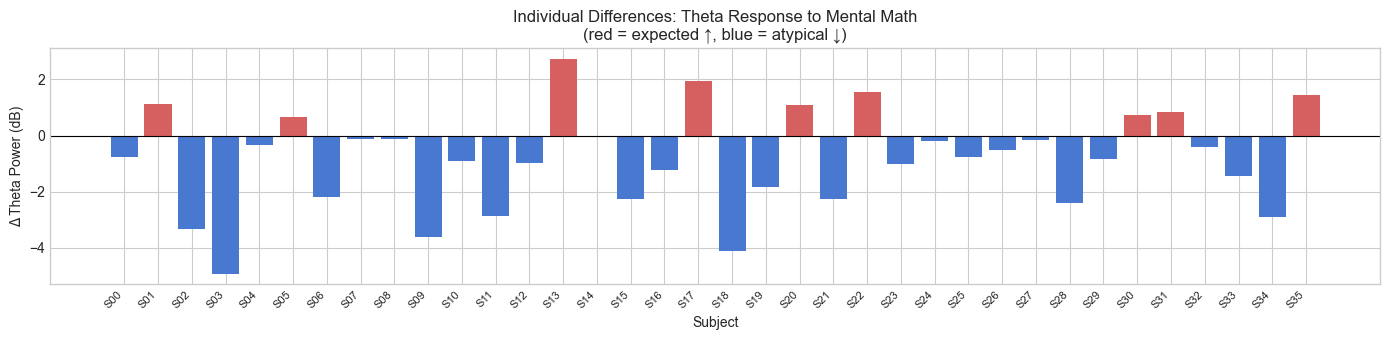

Theta responders : 9/36
Mean Δtheta      : -0.85 dB  (std: 1.74)


In [10]:
delta_theta  = subj_math_theta - subj_rest_theta
colors_delta = ['#D65F5F' if d>0 else '#4878CF' for d in delta_theta]

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(len(unique_subjects)), delta_theta, color=colors_delta)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(unique_subjects)))
ax.set_xticklabels([f'S{s:02d}' for s in unique_subjects], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Subject')
ax.set_ylabel('Δ Theta Power (dB)')
ax.set_title('Individual Differences: Theta Response to Mental Math\n'
             '(red = expected ↑, blue = atypical ↓)')
plt.tight_layout()
plt.show()

n_resp = (delta_theta > 0).sum()
print(f'Theta responders : {n_resp}/{len(unique_subjects)}')
print(f'Mean Δtheta      : {delta_theta.mean():.2f} dB  (std: {delta_theta.std():.2f})')

## 8. Class Balance and Epoch Distribution

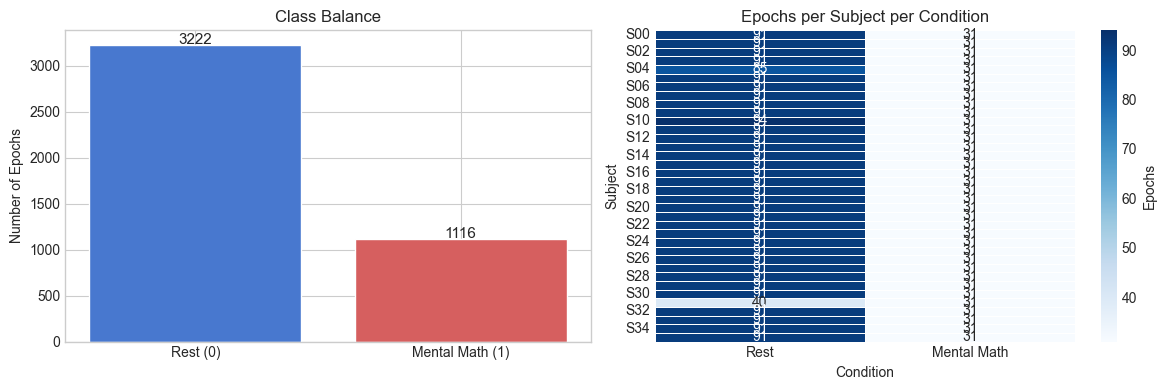

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance bar
counts = np.bincount(y)
axes[0].bar(['Rest (0)', 'Mental Math (1)'], counts,
            color=[COLORS['rest'], COLORS['mental_math']], edgecolor='white')
axes[0].set_ylabel('Number of Epochs')
axes[0].set_title('Class Balance')
for i, c in enumerate(counts):
    axes[0].text(i, c+10, str(c), ha='center', fontsize=11)

# Epochs-per-subject heatmap
epoch_matrix = np.array([
    [((subject_ids==s)&(y==0)).sum(), ((subject_ids==s)&(y==1)).sum()]
    for s in unique_subjects
], dtype=int)
df_heat = pd.DataFrame(epoch_matrix,
                        index=[f'S{s:02d}' for s in unique_subjects],
                        columns=['Rest', 'Mental Math'])
sns.heatmap(df_heat, ax=axes[1], cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Epochs'})
axes[1].set_title('Epochs per Subject per Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Subject')

plt.tight_layout()
plt.show()